# Notebook 6: FLIKE Emulator — Frequentist FFA via LH-moments

## What is FLIKE?

**FLIKE** (now TUFLOW FLIKE, originally Kuczera 1999) is the standard frequentist software for at-site flood frequency analysis in Australian practice. It fits probability distributions (GEV, LP3, Gumbel) to an AMS using two complementary approaches: a Bayesian inference framework and an **L-moments / LH-moments** approach. This notebook emulates the LH-moments workflow.

## L-moments: A Robust Alternative to Conventional Moments

Traditional method-of-moments estimation (used in LP3 under Bulletin 17C/ARR) fits distributions by matching the sample **mean**, **variance**, and **skewness** to their theoretical equivalents. This approach has a critical weakness: sample moments — especially skewness — are highly sensitive to outliers. A single extraordinary event (like 2021 in our dataset) can dominate the skewness estimate and destabilise the entire fit.

**L-moments** (Hosking 1990) solve this by replacing conventional moments with **linear combinations of order statistics** (the data ranked in ascending order):

| L-moment | Symbol | Role |
|---|---|---|
| First ($\lambda_1$) | Location | Equivalent to the mean |
| Second ($\lambda_2$) | Scale | Robust measure of spread |
| L-skewness ratio ($\tau_3 = \lambda_3/\lambda_2$) | Asymmetry | Far less sensitive to outliers than sample skewness |
| L-kurtosis ratio ($\tau_4 = \lambda_4/\lambda_2$) | Tail weight | Used for goodness-of-fit testing |

Because they are linear in the data values (via rank weights), L-moments cannot be dominated by a single extreme observation the way sample skewness can.

## LH-moments: Focusing on the Upper Tail

Standard L-moments weight all observations equally via their ranks. In many flood records, low-flow years — drought years where the "annual maximum" was trivially small — exert significant downward influence on the fit even though engineers are primarily concerned with the upper tail.

**LH-moments** (Wang 1997) generalise L-moments with a **shift parameter** $\eta \in \{0, 1, 2, 3, 4\}$ that progressively reweights the order statistics to emphasise higher-ranked (larger) observations:

- $\eta = 0$: Standard L-moments — all observations equally weighted.
- $\eta = 1$: Observations weighted toward the upper half of the record.
- $\eta = 2, 3, 4$: Increasing focus on the upper tail; low flows contribute negligibly.

A higher shift effectively **discards the influence of flows below approximately the $\eta/(n+1)$ quantile**, allowing the fitted curve to track the behaviour of large floods without being pulled down by near-zero drought years.

**The optimised shift search** tests $\eta = 0$ through 4 and selects the smallest shift for which the fourth LH-moment ($\lambda_4$) of the fitted distribution matches the sample — a goodness-of-fit criterion that confirms the upper tail is adequately captured.

## The FLIKE Workflow

1. **MGBT preprocessing** — detect and flag low outliers (PILFs) before fitting.
2. **LH-moment fitting** — match theoretical and sample PWMs for shifts $\eta = 0$ through 4.
3. **Optimised shift selection** — pick the best $\eta$ based on goodness-of-fit.
4. **Parametric bootstrap** — generate uncertainty bounds by simulating N datasets from the fitted distribution, refitting each, and computing the 5th/95th percentile envelope.

This notebook runs GEV and LP3 through this workflow and compares the output with the Bayesian estimates from Notebooks 1 and 2.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from flood_ffa.data.bom import load_ams, get_flow_series
from flood_ffa.flike import FLIKE
from flood_ffa.plots_lh import plot_flike_results

## 1. Load AMS Data

Same 55-year AMS as all previous notebooks. Note: the 2021 event (121.9 m³/s) is the primary motivation for testing $\eta > 0$ shifts — it sits in the upper tail and we want the fit to track it accurately without low-flow years pulling the curve downward.

In [2]:
df = load_ams("../data/AMS.csv")
flows = get_flow_series(df)
flows.tail()

year
2020     15.6
2021    121.9
2022     48.3
2023     25.4
2024     13.5
Name: flow_m3s, dtype: float64

## 2. GEV Model with Optimised Shift

We run the full FLIKE workflow for the GEV distribution:

1. **MGBT** — check for low outliers (`klow = 0` expected for this dataset).
2. **Shift search** — fit GEV using LH-moments for $\eta = 0, 1, 2, 3, 4$; select the smallest successful shift.
3. **Optimised shift** — the selected $\eta$ represents the minimum up-weighting needed for a stable, well-fitting upper tail.
4. **Parametric bootstrap** — `n_sim` synthetic datasets simulated from the fitted GEV; each is refit and the 5th/95th percentile of the resulting quantiles forms the confidence envelope.

**Reading the output table:**
- **Expected (m³/s)**: The GEV quantile at each AEP using the LH-moment parameter estimates — the best single estimate, analogous to the posterior median in the Bayesian notebooks.
- **5% / 95% Limits**: Bootstrap confidence limits — the interval within which 90% of refitted quantile estimates fall. These bracket the expected value; narrow limits indicate a well-constrained fit.

Note: `n_sim=100` is used here for speed. Use `n_sim=1000` or more for production uncertainty estimates.

In [3]:
flike_gev = FLIKE(model_type="gev")
# n_sim=500 for demonstration speed, use 1000+ for production
report_gev = flike_gev.run(flows, n_sim=100)

print(f"\nOptimal Shift: h={report_gev['shift']}")
report_gev["quantiles"]

Step 1: Running Multiple Grubbs-Beck Test...
  No low outliers detected.
Step 2: Searching for Optimized Shift (h=0 to 4)...
  Selected shift h=0
Step 3: Running Parametric Bootstrap (n_sim=100) for uncertainty...

Optimal Shift: h=0


,AEP (%),Expected (m3/s),5% Limit,95% Limit
0,10.0,17.4,22.6,37.6
1,5.0,18.8,28.2,55.2
2,2.0,20.1,38.2,91.4
3,1.0,20.8,46.0,128.8
4,0.5,21.4,55.6,194.3
5,0.2,21.9,69.7,324.3


### 2b. GEV Probability Plot

The probability plot shows:
- **Points**: Observed AMS at Cunnane plotting positions.
- **Fitted curve**: GEV return level curve at the optimised shift.
- **Confidence band**: 5th–95th bootstrap percentile envelope.

Compare this curve with Notebook 1 (Bayesian GEV). Both fit the same distribution to the same data but use fundamentally different methods:
- **Bayesian**: Full posterior distribution → 94% HDI uncertainty band.
- **LH-moments + bootstrap**: Frequentist point estimate → 90% bootstrap confidence limits.

The bootstrap limits reflect **sampling variability** — uncertainty due to record length — while the Bayesian HDI reflects **parameter uncertainty** as expressed through the posterior. In practice, both bands should span a similar range for the same record length.

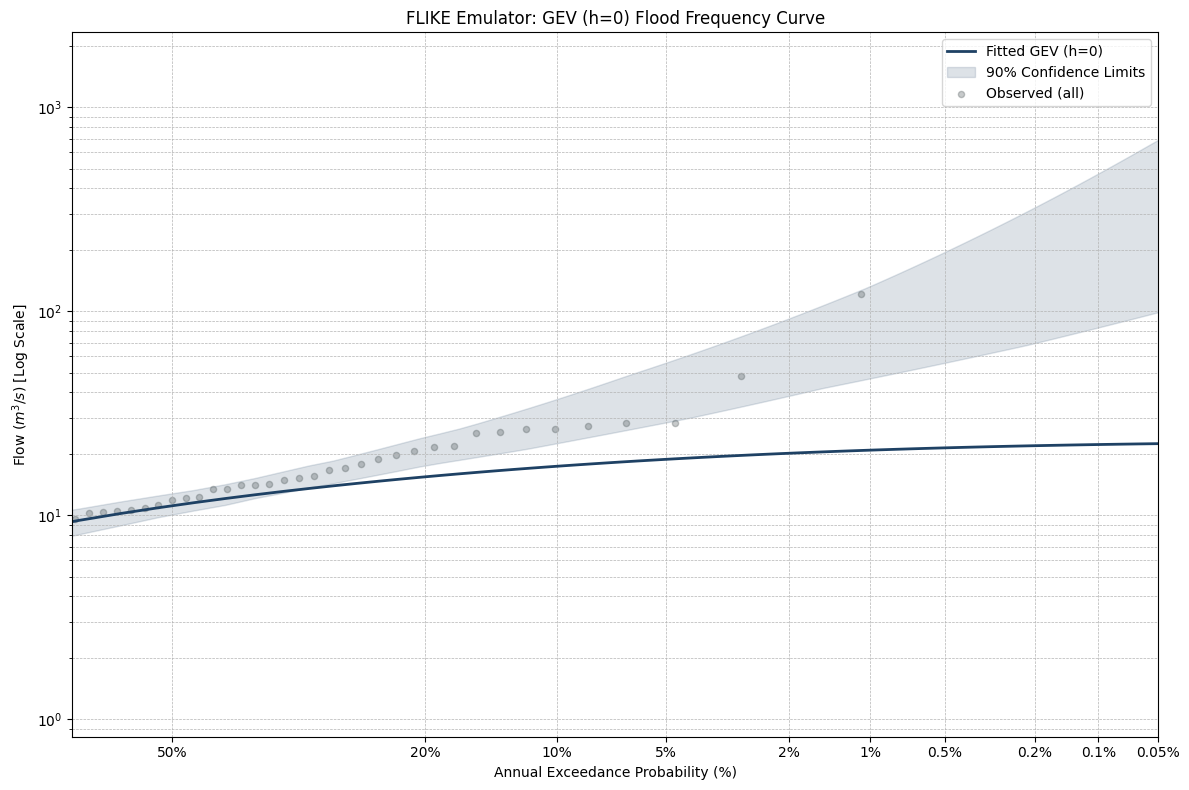

In [4]:
plot_flike_results(flike_gev, flows)
plt.show()

## 3. LP3 Model with Optimised Shift

LP3 fitting via LH-moments follows the same workflow but operates in **log-space** — the LH-moments of $\ln(Q)$ are matched to the Pearson Type 3 theoretical moments.

This is directly analogous to the Bayesian LP3 in Notebook 2, but with a key difference: the LH-moment approach uses a formal goodness-of-fit criterion ($Z_4$ test on the fourth LH-moment) to select the optimal shift, whereas the Bayesian approach uses the prior distribution to regularise the skewness parameter.

**Technical note on the LP3 solver**: The LP3 theoretical PWMs (Probability Weighted Moments) cannot be computed analytically — they require numerical integration of the Pearson Type 3 quantile function. This makes the optimisation objective noisy and slower than the GEV case. If the solver does not converge at `success=True`, the implementation also accepts near-converged solutions with small residuals (`cost < 1e-6`).

In [ ]:
flike_lp3 = FLIKE(model_type="lp3")
report_lp3 = flike_lp3.run(flows, n_sim=100)

print(f"\nOptimal Shift: h={report_lp3['shift']}")
report_lp3["quantiles"]

Step 1: Running Multiple Grubbs-Beck Test...
  No low outliers detected.
Step 2: Searching for Optimized Shift (h=0 to 4)...
  Selected shift h=0
Step 3: Running Parametric Bootstrap (n_sim=100) for uncertainty...


### LP3 Probability Plot

In [ ]:
plot_flike_results(flike_lp3, flows)
plt.show()

## 4. Summary: LH-moments vs Bayesian

Comparing the LH-moment expected quantiles (GEV and LP3) against the Bayesian posterior medians from Notebooks 1 and 2.

**Key points for interpretation:**

1. **Central estimates should be broadly consistent** — both methods fit the same distributions to the same data. Large discrepancies indicate that the LH-moment shift is up-weighting different parts of the record than the Bayesian prior is regularising toward.

2. **Confidence limits (FLIKE) vs HDI (Bayesian)** — these are conceptually different:
   - Bootstrap 90% confidence limits: *"If data were resampled from the fitted distribution, 90% of refitted estimates would fall in this interval."*
   - Bayesian 94% HDI: *"The posterior probability is 94% that the true return level lies in this interval."*

3. **FLIKE's advantage for practitioners** — LH-moments are computationally cheap (no MCMC sampling), run in seconds, and match the TUFLOW FLIKE tool used in Australian practice. Results are directly comparable to regulatory FLIKE outputs.

4. **Bayesian advantage for uncertainty quantification** — the posterior fully characterises parameter uncertainty, handles short records better than asymptotic bootstrap approximations, and naturally incorporates prior information (e.g., regional skewness).

In [ ]:
comparison = pd.merge(
    report_gev["quantiles"][["AEP (%)", "Expected (m3/s)"]],
    report_lp3["quantiles"][["AEP (%)", "Expected (m3/s)"]],
    on="AEP (%)", suffixes=("_GEV", "_LP3")
)
comparison